In [13]:
import pandas as pd 
import matplotlib.pyplot as plt 

df1 = pd.read_csv("../data/round1-data/prices_round_1_day_-2.csv", sep = ";")
df2 = pd.read_csv("../data/round1-data/prices_round_1_day_-1.csv", sep = ";")
df3 = pd.read_csv("../data/round1-data/prices_round_1_day_0.csv", sep = ";")
df1.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0


In [16]:
print(df1.isnull().sum())
print(df1.shape)
print(df1.describe())

day                    0
timestamp              0
product                0
bid_price_1          826
bid_volume_1         826
bid_price_2         6927
bid_volume_2        6927
bid_price_3        19591
bid_volume_3       19591
ask_price_1          805
ask_volume_1         805
ask_price_2         7006
ask_volume_2        7006
ask_price_3        19599
ask_volume_3       19599
mid_price              0
profit_and_loss        0
dtype: int64
(20000, 17)
           day    timestamp   bid_price_1  bid_volume_1   bid_price_2  \
count  20000.0   20000.0000  19174.000000  19174.000000  13073.000000   
mean      -2.0  499950.0000  10242.179410     12.783092  10237.691655   
std        0.0  288682.3503    324.203989      4.918715    323.261897   
min       -2.0       0.0000   9978.000000      2.000000   9978.000000   
25%       -2.0  249975.0000   9990.000000     10.000000   9987.000000   
50%       -2.0  499950.0000  10002.000000     12.000000   9998.000000   
75%       -2.0  749925.0000  10494.0000

### Price Analysis

In [17]:
for prod in df1['product'].unique():
    s = df1[df1['product']==prod]
    mid = s['mid_price'].astype(float)
    spread = s['ask_price_1'].astype(float) - s['bid_price_1'].astype(float)
    
    print(f"\n=== {prod} ===")
    print(f"Mid: {mid[mid>0].iloc[0]:.0f} -> {mid[mid>0].iloc[-1]:.0f} (drift: {mid[mid>0].iloc[-1]-mid[mid>0].iloc[0]:.0f})")
    print(f"Spread: {spread[spread>0].mean():.1f} avg, min={spread[spread>0].min():.0f}, max={spread[spread>0].max():.0f}")
    print(f"Autocorr(1): {mid.diff().autocorr():.3f}")
    print(f"L1 depth: bid={s['bid_volume_1'].mean():.0f} ask={s['ask_volume_1'].mean():.0f}")
    print(f"L2 depth: bid={s['bid_volume_2'].mean():.0f} ask={s['ask_volume_2'].mean():.0f}")


=== INTARIAN_PEPPER_ROOT ===
Mid: 9998 -> 11002 (drift: 1003)
Spread: 12.0 avg, min=2, max=18
Autocorr(1): -0.500
L1 depth: bid=12 ask=12
L2 depth: bid=20 ask=20

=== ASH_COATED_OSMIUM ===
Mid: 10010 -> 9994 (drift: -16)
Spread: 16.1 avg, min=5, max=21
Autocorr(1): -0.500
L1 depth: bid=14 ask=14
L2 depth: bid=24 ask=25


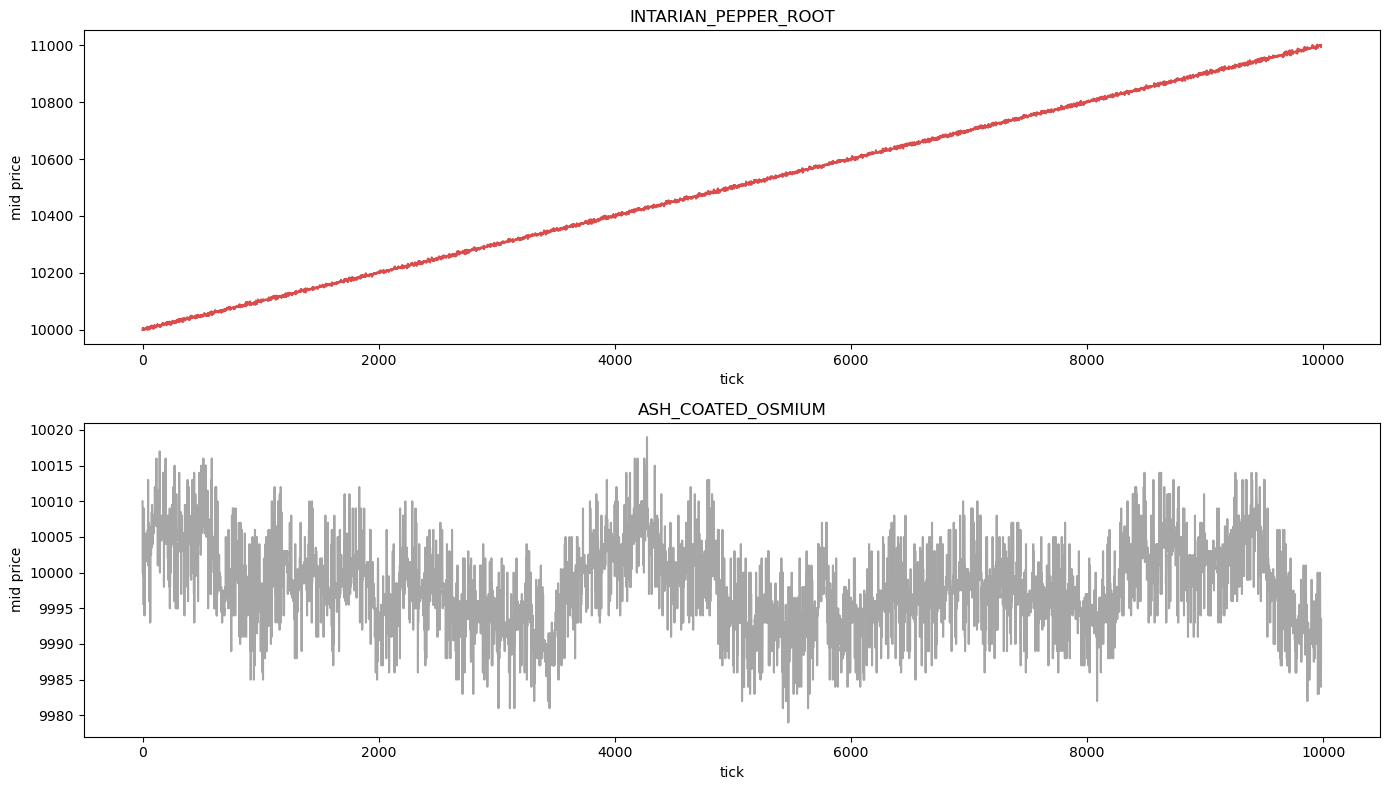

In [22]:
colors = {'INTARIAN_PEPPER_ROOT': '#CC0000', 'ASH_COATED_OSMIUM': '#808080'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for prod, ax in zip(df1['product'].unique(), axes):
    s = df1[df1['product']==prod]
    mid = s['mid_price'].astype(float)
    mid = mid[mid > 0]
    ax.plot(mid.values, alpha=0.7, color=colors[prod])
    ax.set_title(prod)
    ax.set_xlabel("tick")
    ax.set_ylabel("mid price")
plt.tight_layout()

Intarian Pepper ==> Drifiting asset  
Ash Osmium ==> Stationary asset 

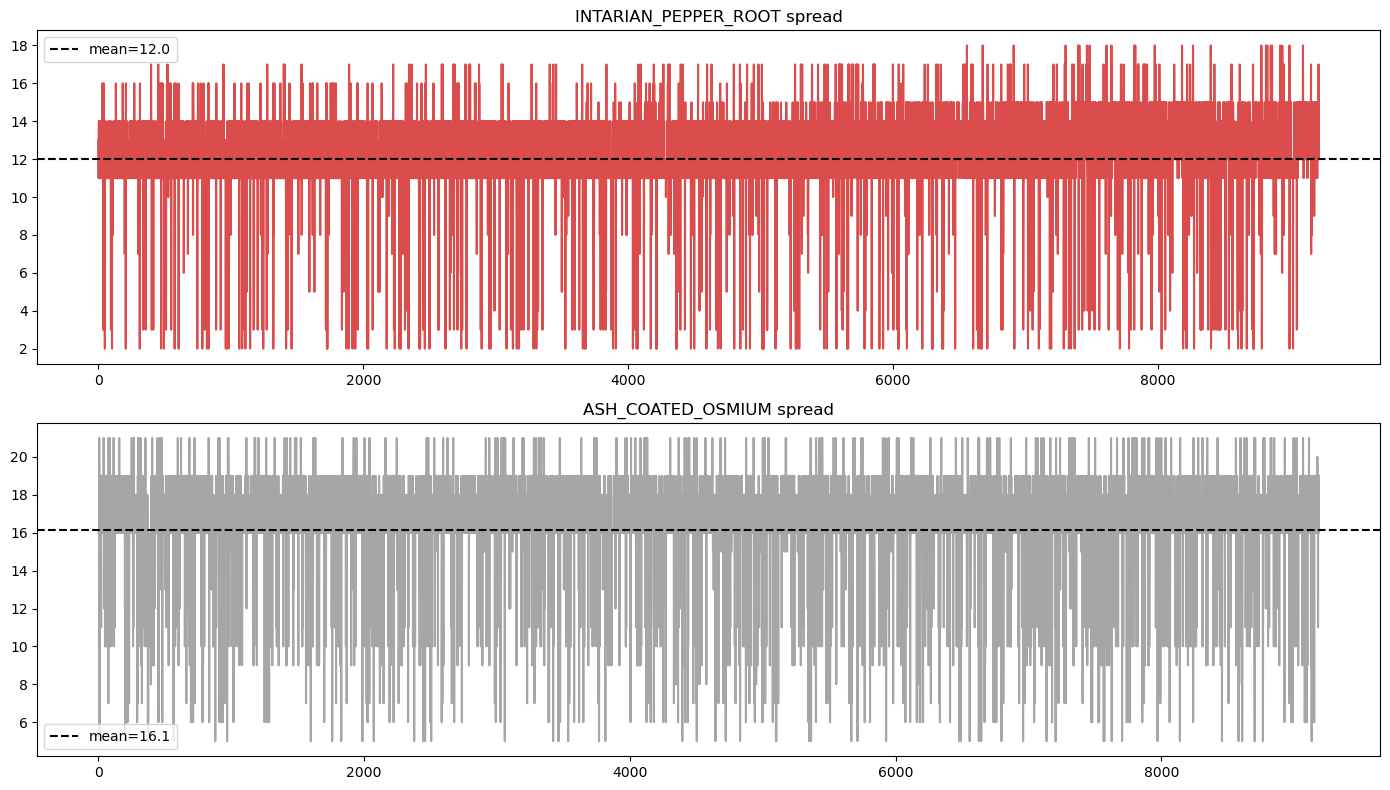

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
colors = {'INTARIAN_PEPPER_ROOT': '#CC0000', 'ASH_COATED_OSMIUM': '#808080'}
for prod, ax in zip(df1['product'].unique(), axes):
    s = df1[df1['product']==prod]
    spread = s['ask_price_1'].astype(float) - s['bid_price_1'].astype(float)
    spread = spread[spread > 0]
    ax.plot(spread.values, alpha=0.7, color=colors[prod])
    ax.axhline(spread.mean(), color='black', ls='--', label=f"mean={spread.mean():.1f}")
    ax.set_title(f"{prod} spread")
    ax.legend()
plt.tight_layout()

### Trade Analysis

In [30]:
tr = pd.read_csv("../data/round1-data/trades_round_1_day_0.csv", sep=";")
for prod in tr['symbol'].unique():
    sub = tr[tr['symbol']==prod]
    print(f"\n=== {prod}: {len(sub)} trades ===")
    print(sub.groupby('price')['quantity'].sum().sort_index())


=== INTARIAN_PEPPER_ROOT: 332 trades ===
price
11998.0    6
12000.0    5
12005.0    6
12007.0    5
12010.0    7
          ..
12986.0    4
12993.0    8
12998.0    6
13002.0    4
13005.0    4
Name: quantity, Length: 278, dtype: int64

=== ASH_COATED_OSMIUM: 411 trades ===
price
9981.0       4
9982.0       6
9983.0      20
9984.0      17
9985.0      18
9986.0      11
9987.0      34
9988.0      59
9989.0      69
9990.0      61
9991.0      65
9992.0      62
9993.0     135
9994.0      77
9995.0      98
9996.0      61
9997.0      65
9998.0      30
9999.0      71
10000.0     71
10001.0     49
10002.0     23
10003.0     71
10004.0     35
10005.0     45
10006.0     87
10007.0     67
10008.0     96
10009.0     98
10010.0     97
10011.0     84
10012.0     62
10013.0     84
10014.0     43
10015.0     56
10016.0     31
10017.0     25
10018.0     17
10019.0     29
10020.0      2
10021.0     12
10023.0      2
10026.0      9
Name: quantity, dtype: int64


Small trades ==> Bots are not agressive, passive makes might get filled easily

In [31]:
for d_file, d_label in [("prices_round_1_day_-2.csv", -2), 
                         ("prices_round_1_day_-1.csv", -1), 
                         ("prices_round_1_day_0.csv", 0)]:
    temp = pd.read_csv(f"../data/round1-data/{d_file}", sep=";")
    for prod in temp['product'].unique():
        s = temp[temp['product']==prod]
        mid = s['mid_price'].astype(float)
        mid = mid[mid>0]
        print(f"Day {d_label} | {prod:25s} | open={mid.iloc[0]:.0f} close={mid.iloc[-1]:.0f} drift={mid.iloc[-1]-mid.iloc[0]:.0f}")
    print()


Day -2 | INTARIAN_PEPPER_ROOT      | open=9998 close=11002 drift=1003
Day -2 | ASH_COATED_OSMIUM         | open=10010 close=9994 drift=-16

Day -1 | INTARIAN_PEPPER_ROOT      | open=10998 close=11998 drift=1000
Day -1 | ASH_COATED_OSMIUM         | open=10003 close=10002 drift=-1

Day 0 | ASH_COATED_OSMIUM         | open=10013 close=10007 drift=-6
Day 0 | INTARIAN_PEPPER_ROOT      | open=11998 close=13000 drift=1002



In [35]:
for prod in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT']:
    for pair in [(-2,-1),(-1,0)]:
        close = df1[(df1.product==prod)&(df1.day==pair[0])].iloc[-1].mid_price
        open_ = df1[(df1.product==prod)&(df1.day==pair[1])].iloc[0].mid_price
        print(f"{prod} day{pair[0]} close={close:.0f} -> day{pair[1]} open={open_:.0f}")

IndexError: single positional indexer is out-of-bounds

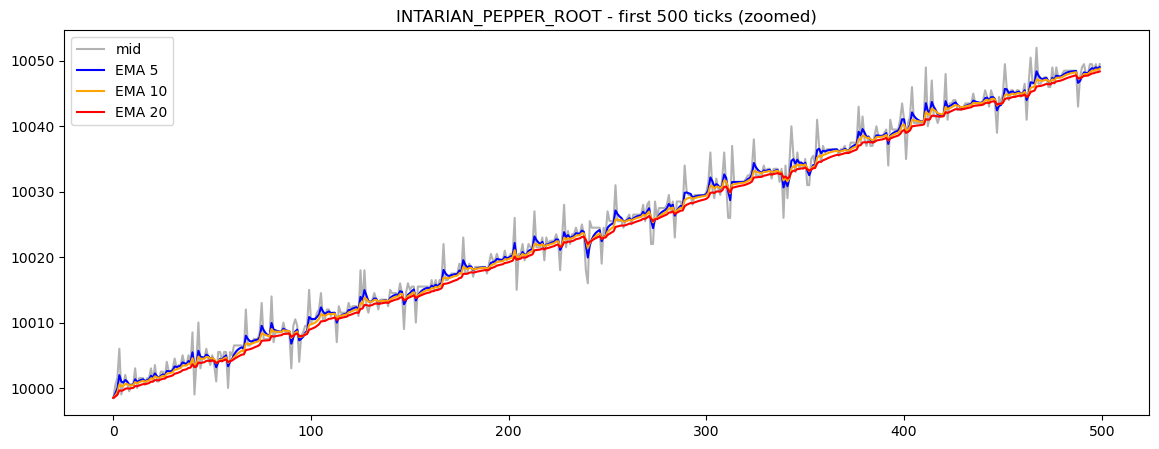

In [33]:
plt.figure(figsize=(14, 5))
window = slice(0, 500)  # first 500 ticks
plt.plot(mid[window], label="mid", alpha=0.3, color='black')
for span, c in [(5,'blue'), (10,'orange'), (20,'red')]:
    alpha = 2/(span+1)
    ema = [mid[0]]
    for p in mid[1:]:
        ema.append(alpha*p + (1-alpha)*ema[-1])
    plt.plot(ema[window], label=f"EMA {span}", color=c)
plt.title("INTARIAN_PEPPER_ROOT - first 500 ticks (zoomed)")
plt.legend()